In [391]:
import pandas as pd
import numpy as np

In [392]:
df=pd.read_csv('dataset copy/train.csv')
df.head()

,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


In [393]:
df.info(),df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          77299 non-null  int64  
 1   geohash        77299 non-null  object 
 2   day            77299 non-null  int64  
 3   timestamp      77299 non-null  object 
 4   demand         77299 non-null  float64
 5   RoadType       76699 non-null  object 
 6   NumberofLanes  77299 non-null  int64  
 7   LargeVehicles  77299 non-null  object 
 8   Landmarks      77299 non-null  object 
 9   Temperature    74804 non-null  float64
 10  Weather        76502 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 6.5+ MB


(None, (77299, 11))

In [394]:
df.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [395]:
df.describe()

,Index,day,demand,NumberofLanes,Temperature
count,77299.000000,77299.000000,7.729900e+04,77299.000000,74804.000000
mean,38649.000000,48.101838,9.394238e-02,2.014334,16.405354
std,22314.443566,0.302438,1.421905e-01,0.904665,7.359835
min,0.000000,48.000000,6.245650e-07,1.000000,-14.935097
25%,19324.500000,48.000000,1.822723e-02,1.000000,11.430473
50%,38649.000000,48.000000,4.775994e-02,2.000000,16.382587
75%,57973.500000,48.000000,1.085951e-01,3.000000,21.298833
max,77298.000000,49.000000,1.000000e+00,5.000000,48.251433


<Axes: xlabel='demand', ylabel='Count'>

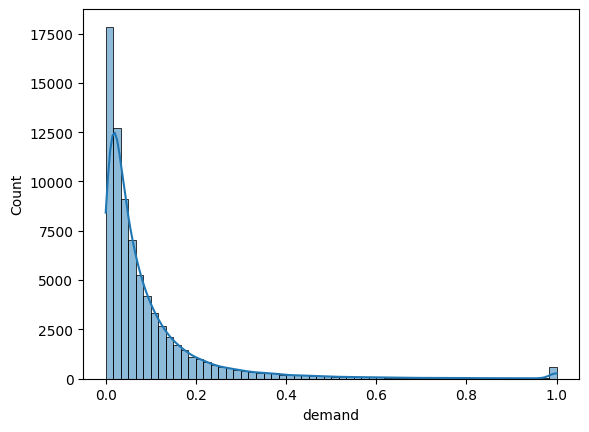

In [396]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['demand'],kde=True,bins=60)

/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/1726662138.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['demand'],shade=True)


<Axes: xlabel='demand', ylabel='Density'>

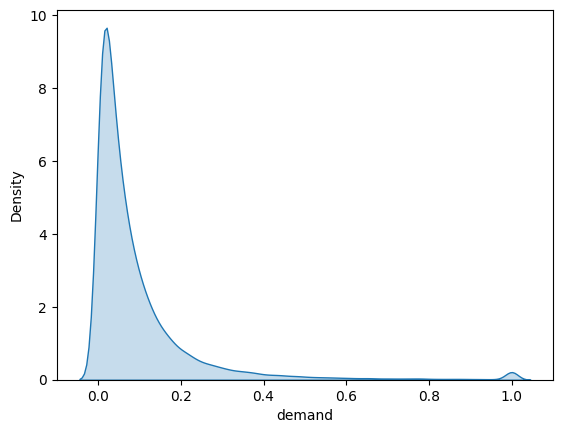

In [397]:
sns.kdeplot(df['demand'],shade=True)

In [398]:
df['demand'].describe()

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64

In [399]:
df['geohash'].nunique()

1249

In [400]:
a=df['demand'].groupby(df['geohash']).mean().sort_values()
a

geohash
qp03zy    0.000495
qp08bt    0.000780
qp09k7    0.000793
qp093h    0.000815
qp09bv    0.000922
            ...   
qp096x    0.665630
qp09d8    0.669318
qp09e5    0.864989
qp09ft    0.868850
qp09d9    0.960715
Name: demand, Length: 1249, dtype: float64

In [401]:
df['geohash'].value_counts()

geohash
qp03xk    105
qp092r    105
qp03wz    105
qp03xp    105
qp097y    105
         ... 
qp097r      1
qp090z      1
qp0dhj      1
qp097n      1
qp09ch      1
Name: count, Length: 1249, dtype: int64

In [402]:
df.groupby('geohash')['demand'].agg(frequency='count', mean_demand='mean').sort_values(by='mean_demand', ascending=False)

,frequency,mean_demand
geohash,,
qp09d9,105,0.960715
qp09ft,105,0.868850
qp09e5,105,0.864989
qp09d8,105,0.669318
qp096x,105,0.665630
...,...,...
qp09bv,1,0.000922
qp093h,1,0.000815
qp09k7,1,0.000793


In [403]:
def convert_to_time(x):
    if pd.isna(x) or ':' not in x:
        return None
    parts=str(x).split(':')
    return float(parts[0]) + float(parts[1])/60

In [404]:
df['timestamp']=df['timestamp'].apply(convert_to_time)

In [405]:
df['timestamp']=df['timestamp']+3
df['timestamp']=np.where(df['timestamp']>23.5,df['timestamp']-23.75,df['timestamp'])

In [406]:
df['demand'].mean()

0.09394238120172715

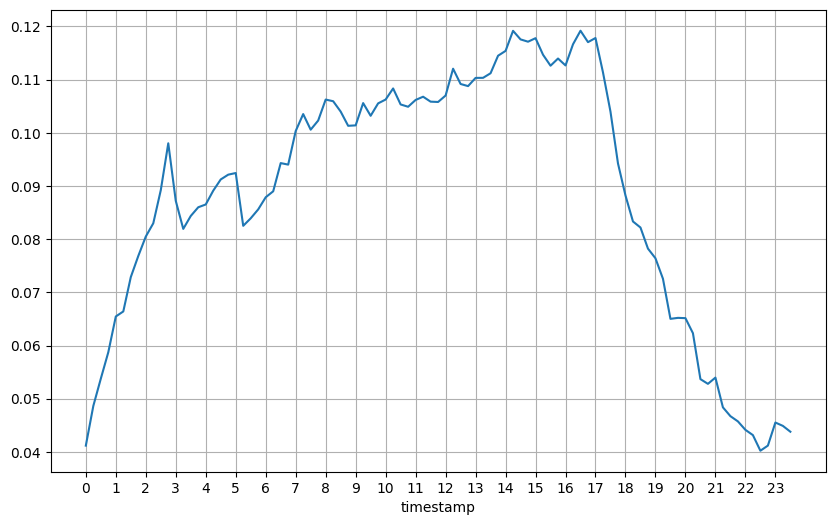

In [407]:
plt.figure(figsize=(10,6))
plt.xticks(np.arange(0,24,step=1))
df['demand'].groupby(df['timestamp']).mean().plot(x='timestamp',y='demand')
plt.grid(True)

In [408]:
df['Weather'].value_counts()

Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64

In [409]:
df['demand'].groupby(df['Weather']).mean()

Weather
Foggy    0.093372
Rainy    0.094471
Snowy    0.092581
Sunny    0.094247
Name: demand, dtype: float64

<Axes: xlabel='Temperature', ylabel='Count'>

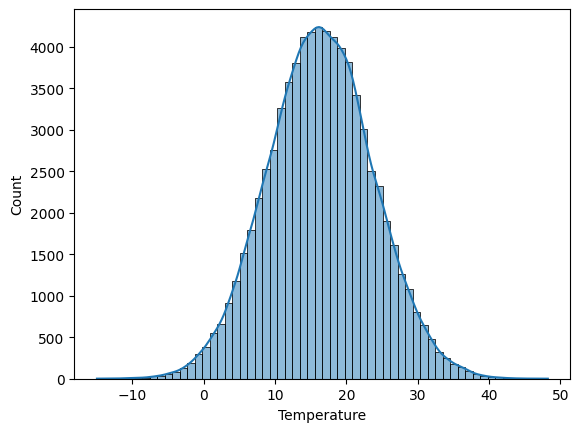

In [410]:
sns.histplot(df['Temperature'],kde=True,bins=60)

In [411]:
df['demand'].corr(df['Temperature'])

0.0031443998795010163

In [412]:
df.corr(numeric_only=True)

,Index,day,timestamp,demand,NumberofLanes,Temperature
Index,1.000000,0.523834,0.157893,-0.001481,-0.001937,-0.006453
day,0.523834,1.000000,-0.341923,0.026807,-0.001222,-0.006755
timestamp,0.157893,-0.341923,1.000000,0.005587,0.007509,-0.003048
demand,-0.001481,0.026807,0.005587,1.000000,0.214148,0.003144
NumberofLanes,-0.001937,-0.001222,0.007509,0.214148,1.000000,0.003232
Temperature,-0.006453,-0.006755,-0.003048,0.003144,0.003232,1.000000


In [413]:
df['demand'].groupby(df['NumberofLanes']).mean()

NumberofLanes
1    0.088104
2    0.077488
3    0.077859
4    0.602882
5    0.607556
Name: demand, dtype: float64

In [414]:
# now looking at all the object type columns except geohash

In [415]:
def see(x):
    return df['demand'].groupby(df[x]).mean()

In [416]:
list=[df.columns[i] for i in range(len(df.columns)) if df.dtypes[i]=='object' and df.columns[i]!='geohash']
list

/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/726939517.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  list=[df.columns[i] for i in range(len(df.columns)) if df.dtypes[i]=='object' and df.columns[i]!='geohash']
/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/726939517.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  list=[df.columns[i] for i in range(len(df.columns)) if df.dtypes[i]=='object' and df.columns[i]!='geohash']
/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/726939517.py:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecate

['RoadType', 'LargeVehicles', 'Landmarks', 'Weather']

In [417]:
def see2(x):
    return df[x].value_counts()

for i in list:
    print(see2(i))

RoadType
Residential    69230
Street          3909
Highway         3560
Name: count, dtype: int64
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
Name: count, dtype: int64


In [418]:
for i in list:
    print(see(i))

RoadType
Highway        0.610756
Residential    0.057209
Street         0.273164
Name: demand, dtype: float64
LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float64
Landmarks
No     0.096295
Yes    0.092801
Name: demand, dtype: float64
Weather
Foggy    0.093372
Rainy    0.094471
Snowy    0.092581
Sunny    0.094247
Name: demand, dtype: float64


# Handling Missing Values

In [419]:
from sklearn.impute import SimpleImputer

newlist=['RoadType','Weather']

imputer=SimpleImputer(strategy='most_frequent')
df[newlist]=imputer.fit_transform(df[newlist])

imputer2=SimpleImputer(strategy='mean')
df['Temperature']=imputer2.fit_transform(df[['Temperature']])

In [420]:
df=df.drop(columns=['Index','day'])

In [421]:
df

,geohash,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,qp02z1,3.0,0.048804,Residential,1,Not Allowed,No,16.405354,Sunny
1,qp02zt,3.0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,qp08bj,3.0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,qp08gt,3.0,0.003272,Residential,1,Not Allowed,No,16.405354,Rainy
4,qp02zq,3.0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy
...,...,...,...,...,...,...,...,...,...
77294,qp0d4n,5.0,0.067203,Residential,1,Not Allowed,No,11.501664,Rainy
77295,qp0d4q,5.0,0.022859,Residential,3,Allowed,Yes,14.715254,Foggy
77296,qp0d4w,5.0,0.141342,Residential,3,Allowed,Yes,19.678860,Sunny
77297,qp0dhw,5.0,0.087574,Residential,1,Not Allowed,No,22.573958,Sunny


# Feature engineering

In [422]:
df['hour_sin']=np.sin(2*np.pi*df['timestamp']/24)
df['hour_cos']=np.cos(2*np.pi*df['timestamp']/24)


for timestamp in df['timestamp']:
    if 0<=timestamp<7:
        df['traffic_phase']=1
    elif 7<=timestamp<17:
        df['traffic_phase']=0
    else:
        df['traffic_phase']=-1

In [423]:
for i in df['traffic_phase']:
    if i==0 :
        df['is_peakrush']=1
    else:
        df['is_peakrush']=0
df['hour_from_peak']=abs(df['timestamp']-17)

# One-Hot Encoding

In [424]:
from sklearn.preprocessing import OneHotEncoder,MinMaxScaler,TargetEncoder,LabelEncoder
from sklearn.compose import ColumnTransformer

In [425]:
df.select_dtypes(include=['object']).columns.drop(['geohash','Weather','Landmarks']).tolist()

['RoadType', 'LargeVehicles']

In [426]:
ohecol=df.select_dtypes(include=['object']).columns.drop(['geohash','Weather','Landmarks']).tolist()
preprocessor=ColumnTransformer(transformers=[
    #('labelencoder',LabelEncoder(),ohecol),
    ('spatial',TargetEncoder(smooth='auto'),['geohash']),
    ('StandardScaler',MinMaxScaler(),['Temperature'])
],remainder='passthrough')

In [427]:
x=df.drop(columns=['demand','Weather','Landmarks'])
y=df['demand']

In [428]:
df_preprocessed=preprocessor.fit_transform(x,y)

In [429]:
ff=preprocessor.get_feature_names_out()
dd=pd.DataFrame(df_preprocessed,columns=ff)

In [430]:
lelist=['remainder__RoadType','remainder__LargeVehicles']
le=LabelEncoder()
for col in lelist:
    dd[col]=le.fit_transform(dd[col])

In [431]:
dd

,spatial__geohash,StandardScaler__Temperature,remainder__timestamp,remainder__RoadType,remainder__NumberofLanes,remainder__LargeVehicles,remainder__hour_sin,remainder__hour_cos,remainder__traffic_phase,remainder__is_peakrush,remainder__hour_from_peak
0,0.037875,0.495999,3.0,1,1,1,0.707107,0.707107,1,0,14.0
1,0.208036,0.728631,3.0,1,3,0,0.707107,0.707107,1,0,14.0
2,0.123521,0.646568,3.0,1,1,1,0.707107,0.707107,1,0,14.0
3,0.015368,0.495999,3.0,1,1,1,0.707107,0.707107,1,0,14.0
4,0.031898,0.407346,3.0,1,1,1,0.707107,0.707107,1,0,14.0
...,...,...,...,...,...,...,...,...,...,...,...
77294,0.027002,0.418392,5.0,1,1,1,0.965926,0.258819,1,0,12.0
77295,0.141181,0.469251,5.0,1,3,0,0.965926,0.258819,1,0,12.0
77296,0.115895,0.547806,5.0,1,3,0,0.965926,0.258819,1,0,12.0
77297,0.077496,0.593624,5.0,1,1,1,0.965926,0.258819,1,0,12.0


In [432]:
dd=dd.join(df['demand'])

In [433]:
## day is omitted 

In [434]:
dd.to_csv('Processed Data.csv',index=False)

# For testing Data

In [435]:
test=pd.read_csv('dataset copy/test.csv')
test.head()

,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [436]:
test.isnull().sum()

Index               0
geohash             0
day                 0
timestamp           0
RoadType          324
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      1349
Weather           431
dtype: int64

In [437]:
test=test.drop(columns=['Index','day'])
test.head()

,geohash,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,qp02z1,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,qp02z9,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,qp02yf,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,qp02z6,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,qp02zd,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [438]:
test['timestamp']=test['timestamp'].apply(convert_to_time)

In [439]:
test['Temperature'].fillna(test['Temperature'].mean(),inplace=True)
for i in newlist:
    test[i].fillna(test[i].mode()[0],inplace=True)

/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/431201273.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Temperature'].fillna(test['Temperature'].mean(),inplace=True)
/var/folders/nc/hvlqvddd2xj11jl0l69nx3580000gn/T/ipykernel_25386/431201273.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are se

In [442]:
test['hour_sin']=np.sin(2*np.pi*test['timestamp']/24)
test['hour_cos']=np.cos(2*np.pi*test['timestamp']/24)


for timestamp in test['timestamp']:
    if 0<=timestamp<7:
        test['traffic_phase']=1
    elif 7<=timestamp<17:
        test['traffic_phase']=0
    else:
        test['traffic_phase']=-1

In [443]:
for i in test['traffic_phase']:
    if i==0 :
        test['is_peakrush']=1
    else:
        test['is_peakrush']=0
test['hour_from_peak']=abs(test['timestamp']-17)

In [444]:
test

,geohash,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,hour_sin,hour_cos,traffic_phase,is_peakrush,hour_from_peak
0,qp02z1,2.25,Residential,1,Not Allowed,No,16.457339,Sunny,0.555570,0.831470,0,1,14.75
1,qp02z9,2.25,Residential,1,Not Allowed,No,6.476213,Snowy,0.555570,0.831470,0,1,14.75
2,qp02yf,2.25,Residential,3,Allowed,Yes,22.318203,Sunny,0.555570,0.831470,0,1,14.75
3,qp02z6,2.25,Residential,2,Not Allowed,Yes,16.457339,Rainy,0.555570,0.831470,0,1,14.75
4,qp02zd,2.25,Residential,1,Not Allowed,No,18.266162,Foggy,0.555570,0.831470,0,1,14.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41773,qp0d4q,13.75,Street,1,Not Allowed,Yes,19.588991,Sunny,-0.442289,-0.896873,0,1,3.25
41774,qp0d4w,13.75,Residential,2,Not Allowed,Yes,10.735538,Rainy,-0.442289,-0.896873,0,1,3.25
41775,qp0dhq,13.75,Residential,2,Not Allowed,Yes,13.223750,Rainy,-0.442289,-0.896873,0,1,3.25
41776,qp0dhw,13.75,Residential,2,Not Allowed,Yes,12.510917,Rainy,-0.442289,-0.896873,0,1,3.25


In [445]:
testx=preprocessor.transform(test)

In [446]:
tf=preprocessor.get_feature_names_out()

In [447]:
tf

array(['spatial__geohash', 'StandardScaler__Temperature',
       'remainder__timestamp', 'remainder__RoadType',
       'remainder__NumberofLanes', 'remainder__LargeVehicles',
       'remainder__hour_sin', 'remainder__hour_cos',
       'remainder__traffic_phase', 'remainder__is_peakrush',
       'remainder__hour_from_peak'], dtype=object)

In [448]:
testx=pd.DataFrame(testx,columns=tf)

In [449]:
lelist=['remainder__RoadType','remainder__LargeVehicles']
le=LabelEncoder()
for col in lelist:
    testx[col]=le.fit_transform(testx[col])

In [450]:
testx.to_csv('Processed Test Data.csv',index=False)

In [451]:
testx

,spatial__geohash,StandardScaler__Temperature,remainder__timestamp,remainder__RoadType,remainder__NumberofLanes,remainder__LargeVehicles,remainder__hour_sin,remainder__hour_cos,remainder__traffic_phase,remainder__is_peakrush,remainder__hour_from_peak
0,0.040119,0.496822,2.25,1,1,1,0.55557,0.83147,0,1,14.75
1,0.031792,0.338859,2.25,1,1,1,0.55557,0.83147,0,1,14.75
2,0.029433,0.589577,2.25,1,3,0,0.55557,0.83147,0,1,14.75
3,0.040028,0.496822,2.25,1,2,1,0.55557,0.83147,0,1,14.75
4,0.054634,0.525448,2.25,1,1,1,0.55557,0.83147,0,1,14.75
...,...,...,...,...,...,...,...,...,...,...,...
41773,0.138812,0.546384,13.75,2,1,1,-0.442289,-0.896873,0,1,3.25
41774,0.113154,0.406268,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25
41775,0.01808,0.445646,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25
41776,0.075093,0.434365,13.75,1,2,1,-0.442289,-0.896873,0,1,3.25
